In [6]:
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict
from typing import Literal


In [7]:
class State(TypedDict):
    seed : int


graph_builder = StateGraph(State)

In [8]:
def node_one(state: State):
   print("node_one ->", state)
   return {}

def node_two(state: State) -> State:
    print("node_two ->", state)
    return {}

def node_three(state: State):
    print("node_three ->", state)
    return { }
def node_four(state: State):
    print("node_four ->", state)
    return {}

In [9]:
graph_builder.add_node("node_one",node_one)
graph_builder.add_node("node_two",node_two)
graph_builder.add_node("node_three",node_three)
graph_builder.add_node("node_four",node_four)

def decide_path(state:State):
    return state["seed"] % 2 == 0

graph_builder.add_conditional_edges(
    START, decide_path, {
        True: "node_one",
        False: "node_two",
        "hello": END}
)
graph_builder.add_edge("node_one","node_two")
graph_builder.add_conditional_edges(
    "node_two", decide_path, {
        True: "node_three",
        False: "node_four",
        "hello": END}
)
graph_builder.add_edge("node_three",END)


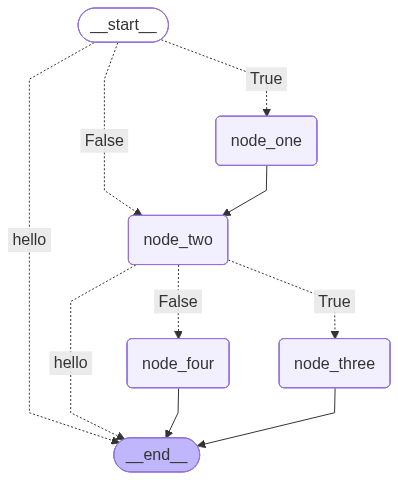

In [10]:
graph = graph_builder.compile()
graph